# Preventable Hospitalisations Among Indigenous Australians
## A Statistical Analysis of Geographic, Socioeconomic, and Clinical Drivers

**Course:** Statistical Thinking for Data Science
**Data Source:** Australian Institute of Health and Welfare (AIHW) — Potentially Preventable Hospitalisations (HPF 50–51)
**Study Period:** 2012–13 to 2017–18
**Geographic Scope:** 31 Primary Health Networks (PHNs) across Australia

---

### Project Overview

Potentially Preventable Hospitalisations (PPH) are admissions for conditions where appropriate and timely primary care could have prevented or reduced the need for hospitalisation. For Indigenous Australians, PPH rates are substantially higher than the general population, reflecting persistent gaps in access to primary care, geographic remoteness, and socioeconomic disadvantage.

This notebook consolidates all analysis into a single reproducible workflow:

| Section | Content |
|---------|---------|
| 1 | PHN-Level Data Loading & Preprocessing |
| 2 | PHN-Level Exploratory Data Analysis |
| 3 | Indigenous Condition-Level Dataset |
| 4 | Indigenous Condition-Level EDA |
| 5 | Model 1 — OLS Regression: What drives regional PPH variation? |
| 6 | Model 2 — Random Forest: Predicting average length of stay |
| 7 | Key Findings & Recommendations |

### Research Questions
1. What geographic and socioeconomic factors explain variation in PPH rates across Australia's 31 PHNs?
2. Which conditions drive the greatest hospitalisation burden among Indigenous Australians, and how has this changed over 2012–2018?
3. Can we accurately predict average length of stay (LOS) for PPH admissions based on condition, category, sex, and year?


In [1]:
# ── Standard libraries ─────────────────────────────────────────────────────
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns

# ── Statistical modelling ──────────────────────────────────────────────────
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import scipy.stats as stats

# ── Machine learning ───────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Paths (relative to this notebook's location) ───────────────────────────
BASE      = Path("..")
RAW_DATA  = BASE / "pre-processed-datasets"
PROC_DATA = BASE / "processed-datasets"

# ── Global plot style ──────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":       "serif",
    "font.serif":        ["Georgia", "DejaVu Serif"],
    "axes.facecolor":    "#F7F4EF",
    "figure.facecolor":  "#F7F4EF",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#DDDDDD",
    "grid.linewidth":    0.6,
})

CATEGORY_COLORS = {
    "Chronic PPH":             "teal",
    "Acute PPH":               "coral",
    "Vaccine preventable PPH": "sandybrown",
}

print("Environment ready.")
print(f"  Raw data  : {RAW_DATA.resolve()}")
print(f"  Processed : {PROC_DATA.resolve()}")


Environment ready.
  Raw data  : C:\Users\abdul\OneDrive\Documents\UTS-PROJECTS\Statistical-Thinking-for-Data-Science\australia-preventable-hospitalisations\pre-processed-datasets
  Processed : C:\Users\abdul\OneDrive\Documents\UTS-PROJECTS\Statistical-Thinking-for-Data-Science\australia-preventable-hospitalisations\processed-datasets


---
## Section 1 — PHN-Level Data Loading & Preprocessing

**Source:** AIHW HPF 50–51, Table A1 — Potentially Preventable Hospitalisations by Primary Health Network
**Unit of observation:** 31 Australian Primary Health Networks (PHNs)

**Processing pipeline:**
1. Load `A1.csv` — rename columns, strip commas and `n.p.` suppressions, cast to numeric
2. Load `remoteness.csv` — aggregate average age-standardised PPH rate per remoteness category; manually map each PHN to a remoteness class
3. Load `socio-economic-area.csv` — aggregate average PPH rate per SEIFA quintile; manually map each PHN to a SEIFA class
4. Merge into a single master dataset with no missing values across key predictors


In [2]:
# ── Load raw A1.csv ────────────────────────────────────────────────────────
df_raw = pd.read_csv(RAW_DATA / "A1.csv")
print("Raw shape:", df_raw.shape)

# Rename all 14 columns
df_raw.columns = [
    "phn_code", "phn_name",
    "pph_number", "pph_per_100_residents", "drop1",
    "indigenous_health_checks_number", "health_checks_per_1000_indigenous", "drop2",
    "pad_number", "pad_per_100000_indigenous", "drop3",
    "indigenous_followup_number", "followup_per_100_indigenous", "drop4",
]

df = df_raw.drop(columns=["drop1", "drop2", "drop3", "drop4"])

# Clean numeric columns: remove commas and n.p. suppressions
def clean_numeric(series):
    return (
        series.astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("n.p.", "", regex=False)
        .str.strip()
        .replace("", np.nan)
    )

numeric_cols = [
    "pph_number", "pph_per_100_residents",
    "indigenous_health_checks_number", "health_checks_per_1000_indigenous",
    "pad_number", "pad_per_100000_indigenous",
    "indigenous_followup_number", "followup_per_100_indigenous",
]
for col in numeric_cols:
    df[col] = pd.to_numeric(clean_numeric(df[col]), errors="coerce")

df["phn_name"] = df["phn_name"].str.strip()
df = df.drop_duplicates().reset_index(drop=True)

# Keep only core columns for master dataset
master_df = df[["phn_code", "phn_name", "pph_per_100_residents",
                 "health_checks_per_1000_indigenous"]].copy()

print(f"Master shape after A1 load: {master_df.shape}")
print(f"Missing values:\n{master_df.isnull().sum()}")
master_df.head()


Raw shape: (31, 14)
Master shape after A1 load: (31, 4)
Missing values:
phn_code                             0
phn_name                             0
pph_per_100_residents                0
health_checks_per_1000_indigenous    0
dtype: int64


,phn_code,phn_name,pph_per_100_residents,health_checks_per_1000_indigenous
0,101,Central and Eastern Sydney,1.0,34.4
1,102,Northern Sydney,0.4,15.4
2,103,Western Sydney,1.6,41.5
3,104,Nepean Blue Mountains,3.2,29.3
4,105,South Western Sydney,1.8,31.5


In [3]:
# ── Load remoteness.csv and build PHN-level remoteness feature ────────────
rem_raw = pd.read_csv(RAW_DATA / "remoteness.csv", encoding="cp1252")
rem_raw.columns = [
    "reporting_year", "remoteness_area", "sex", "pph_category",
    "pph_condition", "population", "pph_age_standardised", "pph_crude",
    "number_of_pph", "same_day_pph", "same_day_percentage",
    "total_pph_bed_days", "avg_length_of_stay",
]

# Clean numerics
for col in ["population", "pph_age_standardised", "pph_crude", "number_of_pph",
            "same_day_pph", "same_day_percentage", "total_pph_bed_days", "avg_length_of_stay"]:
    rem_raw[col] = pd.to_numeric(
        rem_raw[col].astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("n.p.", "", regex=False)
        .str.strip().replace("", np.nan),
        errors="coerce"
    )

# Persons only, then aggregate mean PPH rate per remoteness area
rem_persons = rem_raw[rem_raw["sex"].str.strip().str.lower() == "persons"].copy()
rem_summary = (
    rem_persons.groupby("remoteness_area", as_index=False)
    ["pph_age_standardised"].mean()
    .rename(columns={"pph_age_standardised": "remoteness_pph_avg"})
)
print("Remoteness summary:")
print(rem_summary.to_string(index=False))

# Manual PHN → remoteness mapping (ASGS classification)
PHN_REMOTENESS = {
    "Central and Eastern Sydney": "Major cities",   "Northern Sydney": "Major cities",
    "Western Sydney": "Major cities",               "South Western Sydney": "Major cities",
    "North Western Melbourne": "Major cities",      "Eastern Melbourne": "Major cities",
    "South Eastern Melbourne": "Major cities",      "Brisbane North": "Major cities",
    "Brisbane South": "Major cities",               "Gold Coast": "Major cities",
    "Adelaide": "Major cities",                     "Perth North": "Major cities",
    "Perth South": "Major cities",                  "Australian Capital Territory": "Major cities",
    "Nepean Blue Mountains": "Inner Regional",      "South Eastern NSW": "Inner Regional",
    "Hunter New England and Central Coast": "Inner Regional",
    "North Coast": "Inner Regional",                "Murrumbidgee": "Inner Regional",
    "Gippsland": "Inner Regional",                  "Murray": "Inner Regional",
    "Western Victoria": "Inner Regional",           "Tasmania": "Inner Regional",
    "Darling Downs and West Moreton": "Outer Regional",
    "Central Queensland, Wide Bay, Sunshine Coast": "Outer Regional",
    "Western NSW": "Remote",                        "Western Queensland": "Remote",
    "Northern Queensland": "Remote",                "Country SA": "Remote",
    "Country WA": "Remote",
    "Northern Territory": "Very Remote",
}

master_df = master_df.copy()
master_df["remoteness_area"] = master_df["phn_name"].map(PHN_REMOTENESS)
master_df = master_df.merge(rem_summary, on="remoteness_area", how="left")
print(f"\nMissing after remoteness merge: {master_df.isnull().sum().sum()}")


Remoteness summary:
remoteness_area  remoteness_pph_avg
 Inner Regional          312.446809
   Major cities          281.192708
 Outer Regional          357.768817
         Remote          517.563536
    Very Remote          770.491713

Missing after remoteness merge: 0


In [4]:
# ── Load socio-economic-area.csv and build PHN-level SEIFA feature ─────────
socio_raw = pd.read_csv(RAW_DATA / "socio-economic-area.csv", encoding="cp1252", low_memory=False)
socio_raw.columns = [
    "reporting_year", "seifa_quintile", "sex", "pph_category",
    "pph_condition", "population", "pph_age_standardised", "pph_crude",
    "number_of_pph", "same_day_pph", "same_day_percentage",
    "total_pph_bed_days", "avg_length_of_stay",
]

for col in ["population", "pph_age_standardised", "pph_crude", "number_of_pph",
            "same_day_pph", "same_day_percentage", "total_pph_bed_days", "avg_length_of_stay"]:
    socio_raw[col] = pd.to_numeric(
        socio_raw[col].astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("n.p.", "", regex=False)
        .str.strip().replace("", np.nan),
        errors="coerce"
    )

socio_persons = socio_raw[socio_raw["sex"].str.strip().str.lower() == "persons"].copy()
socio_summary = (
    socio_persons.groupby("seifa_quintile", as_index=False)
    ["pph_age_standardised"].mean()
    .rename(columns={"pph_age_standardised": "seifa_pph_avg"})
)
print("SEIFA summary:")
print(socio_summary.to_string(index=False))

# Manual PHN → SEIFA mapping
PHN_SEIFA = {
    "Central and Eastern Sydney": "SEIFA 5 (Least disadvantaged)",
    "Northern Sydney":            "SEIFA 5 (Least disadvantaged)",
    "Eastern Melbourne":          "SEIFA 5 (Least disadvantaged)",
    "Perth North":                "SEIFA 5 (Least disadvantaged)",
    "Australian Capital Territory": "SEIFA 5 (Least disadvantaged)",
    "North Western Melbourne": "SEIFA 4", "South Eastern Melbourne": "SEIFA 4",
    "Western Sydney": "SEIFA 3",          "Brisbane North": "SEIFA 3",
    "Brisbane South": "SEIFA 3",          "Gold Coast": "SEIFA 3",
    "Adelaide": "SEIFA 3",                "Perth South": "SEIFA 3",
    "Nepean Blue Mountains": "SEIFA 3",
    "South Western Sydney": "SEIFA 2",    "South Eastern NSW": "SEIFA 2",
    "Hunter New England and Central Coast": "SEIFA 2",
    "North Coast": "SEIFA 2",             "Murrumbidgee": "SEIFA 2",
    "Tasmania": "SEIFA 2",                "Gippsland": "SEIFA 2",
    "Murray": "SEIFA 2",                  "Western Victoria": "SEIFA 2",
    "Darling Downs and West Moreton": "SEIFA 2",
    "Central Queensland, Wide Bay, Sunshine Coast": "SEIFA 2",
    "Northern Queensland": "SEIFA 2",
    "Western NSW":    "SEIFA 1 (Most disadvantaged)",
    "Northern Territory": "SEIFA 1 (Most disadvantaged)",
    "Country WA":     "SEIFA 1 (Most disadvantaged)",
    "Country SA":     "SEIFA 1 (Most disadvantaged)",
    "Western Queensland": "SEIFA 1 (Most disadvantaged)",
}

master_df["seifa_quintile"] = master_df["phn_name"].map(PHN_SEIFA)
master_df = master_df.merge(socio_summary, on="seifa_quintile", how="left")
print(f"\nFinal master shape: {master_df.shape}")
print(f"Missing values:\n{master_df.isnull().sum()}")


SEIFA summary:
               seifa_quintile  seifa_pph_avg
 SEIFA 1 (Most disadvantaged)     390.349206
                      SEIFA 2     324.718750
                      SEIFA 3     298.619048
                      SEIFA 4     273.564516
SEIFA 5 (Least disadvantaged)     238.629032

Final master shape: (31, 8)
Missing values:
phn_code                             0
phn_name                             0
pph_per_100_residents                0
health_checks_per_1000_indigenous    0
remoteness_area                      0
remoteness_pph_avg                   0
seifa_quintile                       0
seifa_pph_avg                        0
dtype: int64


In [5]:
# ── Final master dataset ──────────────────────────────────────────────────
# Add ordered categoricals for plotting
REMOTENESS_ORDER = ["Major cities", "Inner Regional", "Outer Regional", "Remote", "Very Remote"]
SEIFA_ORDER = ["SEIFA 1 (Most disadvantaged)", "SEIFA 2", "SEIFA 3",
               "SEIFA 4", "SEIFA 5 (Least disadvantaged)"]

master_df["remoteness_area"] = pd.Categorical(master_df["remoteness_area"],
                                               categories=REMOTENESS_ORDER, ordered=True)
master_df["seifa_quintile"]  = pd.Categorical(master_df["seifa_quintile"],
                                               categories=SEIFA_ORDER, ordered=True)
print(f"Master dataset: {master_df.shape[0]} PHNs × {master_df.shape[1]} columns")
master_df


Master dataset: 31 PHNs × 8 columns


,phn_code,phn_name,pph_per_100_residents,health_checks_per_1000_indigenous,remoteness_area,remoteness_pph_avg,seifa_quintile,seifa_pph_avg
0,101,Central and Eastern Sydney,1.0,34.4,Major cities,281.192708,SEIFA 5 (Least disadvantaged),238.629032
1,102,Northern Sydney,0.4,15.4,Major cities,281.192708,SEIFA 5 (Least disadvantaged),238.629032
2,103,Western Sydney,1.6,41.5,Major cities,281.192708,SEIFA 3,298.619048
3,104,Nepean Blue Mountains,3.2,29.3,Inner Regional,312.446809,SEIFA 3,298.619048
4,105,South Western Sydney,1.8,31.5,Major cities,281.192708,SEIFA 2,324.718750
5,106,South Eastern NSW,3.5,32.0,Inner Regional,312.446809,SEIFA 2,324.718750
6,107,Western NSW,11.5,45.7,Remote,517.563536,SEIFA 1 (Most disadvantaged),390.349206
7,108,Hunter New England and Central Coast,5.1,36.0,Inner Regional,312.446809,SEIFA 2,324.718750
8,109,North Coast,5.5,47.9,Inner Regional,312.446809,SEIFA 2,324.718750
9,110,Murrumbidgee,5.0,47.0,Inner Regional,312.446809,SEIFA 2,324.718750


---
## Section 2 — PHN-Level Exploratory Data Analysis

Six visualisations explore the PHN-level dataset before modelling:

1. **Distribution of PPH rates** — reveals the right-skewed, inequitable spread across regions
2. **PPH by SEIFA quintile** — quantifies the socioeconomic disadvantage gradient
3. **Health checks vs PPH** — exposes the counter-intuitive positive correlation (confounded by remoteness)
4. **Risk score ranking** — combined risk index identifying highest-burden PHNs
5. **Correlation heatmap** — justifies the multivariate regression approach


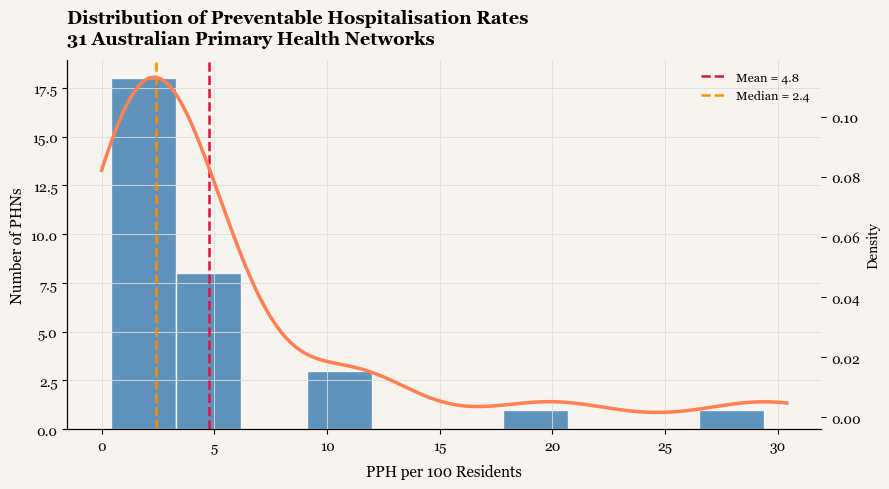

Key insight: The right-skewed distribution reveals a 'long tail' of inequity — a few
remote PHNs experience PPH rates 10–20x higher than the metropolitan median.


In [6]:
# ── Plot 1: Distribution of PPH Rates ────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(master_df["pph_per_100_residents"], bins=10,
        color="steelblue", edgecolor="white", alpha=0.85)

from scipy.stats import gaussian_kde
x_vals = np.linspace(0, master_df["pph_per_100_residents"].max() + 1, 200)
kde = gaussian_kde(master_df["pph_per_100_residents"].dropna(), bw_method=0.4)
ax2 = ax.twinx()
ax2.plot(x_vals, kde(x_vals), color="coral", lw=2.5, label="KDE")
ax2.set_ylabel("Density", fontsize=10)
ax2.spines["top"].set_visible(False)
ax2.grid(False)

ax.axvline(master_df["pph_per_100_residents"].mean(), color="crimson",
           linestyle="--", lw=1.8,
           label=f"Mean = {master_df['pph_per_100_residents'].mean():.1f}")
ax.axvline(master_df["pph_per_100_residents"].median(), color="darkorange",
           linestyle="--", lw=1.8,
           label=f"Median = {master_df['pph_per_100_residents'].median():.1f}")

ax.set_xlabel("PPH per 100 Residents", fontsize=11, labelpad=8)
ax.set_ylabel("Number of PHNs", fontsize=11)
ax.set_title(
    "Distribution of Preventable Hospitalisation Rates\n"
    "31 Australian Primary Health Networks",
    fontsize=13, fontweight="bold", pad=12, loc="left"
)
ax.legend(loc="upper right", frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig("plot_01_pph_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

print("Key insight: The right-skewed distribution reveals a 'long tail' of inequity — a few")
print("remote PHNs experience PPH rates 10–20x higher than the metropolitan median.")


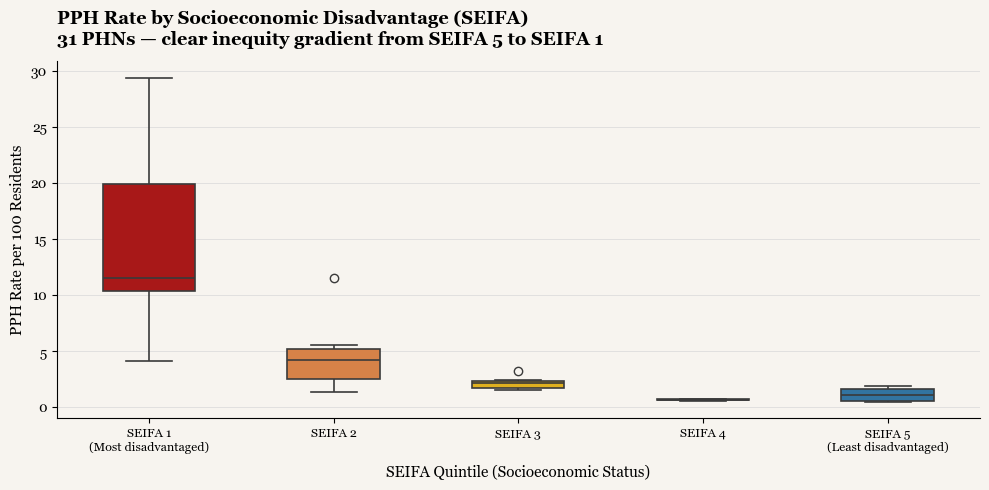

In [7]:
# ── Plot 2: PPH by SEIFA Quintile ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

seifa_colors = {
    "SEIFA 1 (Most disadvantaged)": "#C00000",
    "SEIFA 2": "#ED7D31", "SEIFA 3": "#FFC000",
    "SEIFA 4": "#70AD47",
    "SEIFA 5 (Least disadvantaged)": "#1F77B4",
}

sns.boxplot(
    data=master_df, x="seifa_quintile", y="pph_per_100_residents",
    order=SEIFA_ORDER,
    palette=seifa_colors,
    width=0.5, linewidth=1.2,
    ax=ax
)

ax.set_xlabel("SEIFA Quintile (Socioeconomic Status)", fontsize=11, labelpad=8)
ax.set_ylabel("PPH Rate per 100 Residents", fontsize=11)
ax.set_title(
    "PPH Rate by Socioeconomic Disadvantage (SEIFA)\n"
    "31 PHNs — clear inequity gradient from SEIFA 5 to SEIFA 1",
    fontsize=13, fontweight="bold", pad=12, loc="left"
)
ax.set_xticklabels([l.get_text().replace(" (Most disadvantaged)", "\n(Most disadvantaged)")
                    .replace(" (Least disadvantaged)", "\n(Least disadvantaged)")
                    for l in ax.get_xticklabels()], fontsize=9)

plt.tight_layout()
plt.savefig("plot_02_seifa_boxplot.png", dpi=160, bbox_inches="tight")
plt.show()


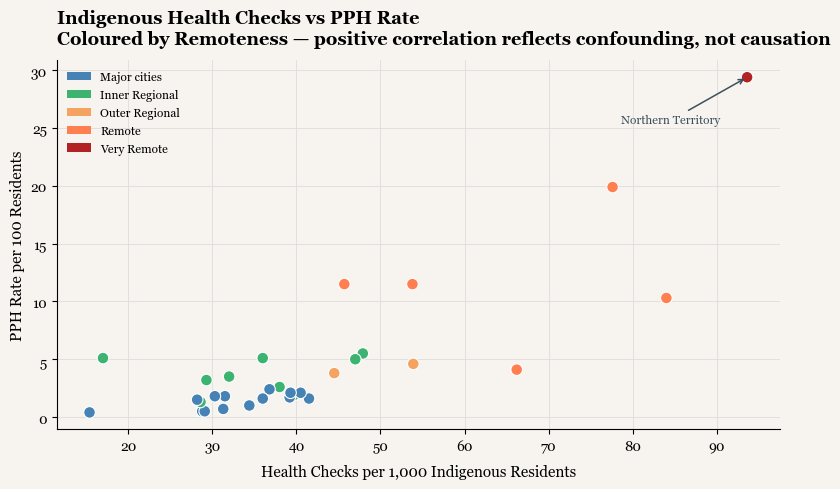

Counter-intuitive finding: More health checks → higher PPH. This is a confounding
effect: health checks are concentrated in the same remote areas with highest need.


In [8]:
# ── Plot 3: Indigenous Health Checks vs PPH Rate ─────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

scatter_colors = [
    {"Major cities": "steelblue", "Inner Regional": "mediumseagreen",
     "Outer Regional": "sandybrown", "Remote": "coral", "Very Remote": "firebrick"}
    [r] for r in master_df["remoteness_area"]
]

ax.scatter(
    master_df["health_checks_per_1000_indigenous"],
    master_df["pph_per_100_residents"],
    c=scatter_colors, s=70, edgecolors="white", linewidth=0.8, zorder=3
)

# Annotate NT
nt = master_df[master_df["phn_name"] == "Northern Territory"].iloc[0]
ax.annotate("Northern Territory",
            xy=(nt["health_checks_per_1000_indigenous"], nt["pph_per_100_residents"]),
            xytext=(nt["health_checks_per_1000_indigenous"] - 15, nt["pph_per_100_residents"] - 4),
            arrowprops=dict(arrowstyle="->", color="#3D4F5C", lw=1.1),
            fontsize=8.5, color="#3D4F5C")

# Legend
legend_elements = [
    Patch(facecolor="steelblue",    label="Major cities"),
    Patch(facecolor="mediumseagreen", label="Inner Regional"),
    Patch(facecolor="sandybrown",   label="Outer Regional"),
    Patch(facecolor="coral",        label="Remote"),
    Patch(facecolor="firebrick",    label="Very Remote"),
]
ax.legend(handles=legend_elements, frameon=False, fontsize=8.5, loc="upper left")

ax.set_xlabel("Health Checks per 1,000 Indigenous Residents", fontsize=11, labelpad=8)
ax.set_ylabel("PPH Rate per 100 Residents", fontsize=11)
ax.set_title(
    "Indigenous Health Checks vs PPH Rate\n"
    "Coloured by Remoteness — positive correlation reflects confounding, not causation",
    fontsize=13, fontweight="bold", pad=12, loc="left"
)

plt.tight_layout()
plt.savefig("plot_03_health_checks_scatter.png", dpi=160, bbox_inches="tight")
plt.show()

print("Counter-intuitive finding: More health checks → higher PPH. This is a confounding")
print("effect: health checks are concentrated in the same remote areas with highest need.")


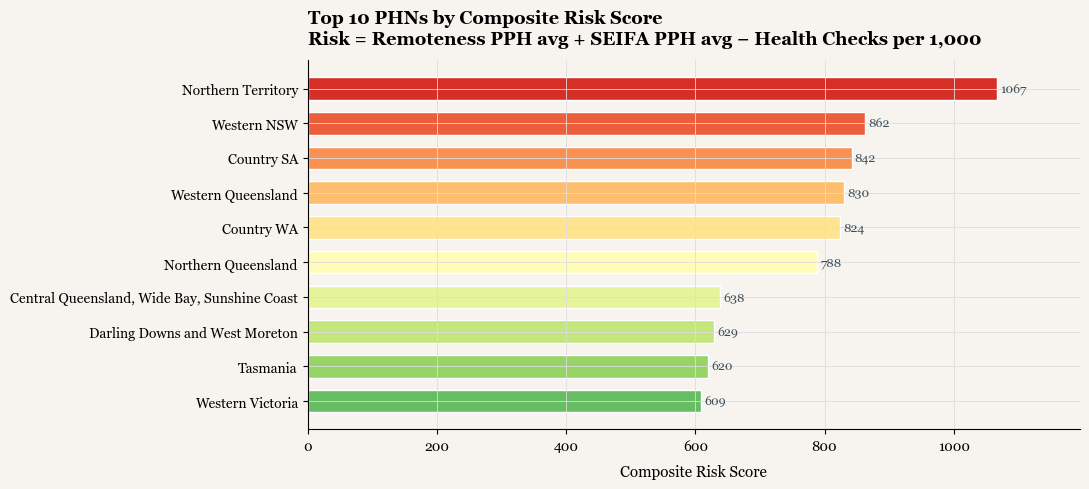


Top 10 High-Risk PHNs:
                                    phn_name  risk_score remoteness_area               seifa_quintile
                          Northern Territory 1067.240919     Very Remote SEIFA 1 (Most disadvantaged)
                                 Western NSW  862.212742          Remote SEIFA 1 (Most disadvantaged)
                                  Country SA  841.712742          Remote SEIFA 1 (Most disadvantaged)
                          Western Queensland  830.312742          Remote SEIFA 1 (Most disadvantaged)
                                  Country WA  823.912742          Remote SEIFA 1 (Most disadvantaged)
                         Northern Queensland  788.482286          Remote                      SEIFA 2
Central Queensland, Wide Bay, Sunshine Coast  637.987567  Outer Regional                      SEIFA 2
              Darling Downs and West Moreton  628.587567  Outer Regional                      SEIFA 2
                                    Tasmania  620.165559  

In [9]:
# ── Plot 4: Risk Score Ranking ────────────────────────────────────────────
master_df["risk_score"] = (
    master_df["remoteness_pph_avg"] +
    master_df["seifa_pph_avg"] -
    master_df["health_checks_per_1000_indigenous"]
)

top10 = master_df.nlargest(10, "risk_score")[["phn_name", "risk_score",
                                               "remoteness_area", "seifa_quintile"]].copy()

fig, ax = plt.subplots(figsize=(11, 5))
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.9, 10))
bars = ax.barh(top10["phn_name"][::-1], top10["risk_score"][::-1],
               color=colors, edgecolor="white", height=0.65)

for bar in bars:
    w = bar.get_width()
    ax.text(w + 5, bar.get_y() + bar.get_height() / 2,
            f"{w:.0f}", va="center", fontsize=9, color="#3D4F5C")

ax.set_xlabel("Composite Risk Score", fontsize=11, labelpad=8)
ax.set_title(
    "Top 10 PHNs by Composite Risk Score\n"
    "Risk = Remoteness PPH avg + SEIFA PPH avg − Health Checks per 1,000",
    fontsize=13, fontweight="bold", pad=12, loc="left"
)
ax.set_xlim(0, top10["risk_score"].max() * 1.12)

plt.tight_layout()
plt.savefig("plot_04_risk_ranking.png", dpi=160, bbox_inches="tight")
plt.show()

print("\nTop 10 High-Risk PHNs:")
print(top10[["phn_name", "risk_score", "remoteness_area", "seifa_quintile"]].to_string(index=False))


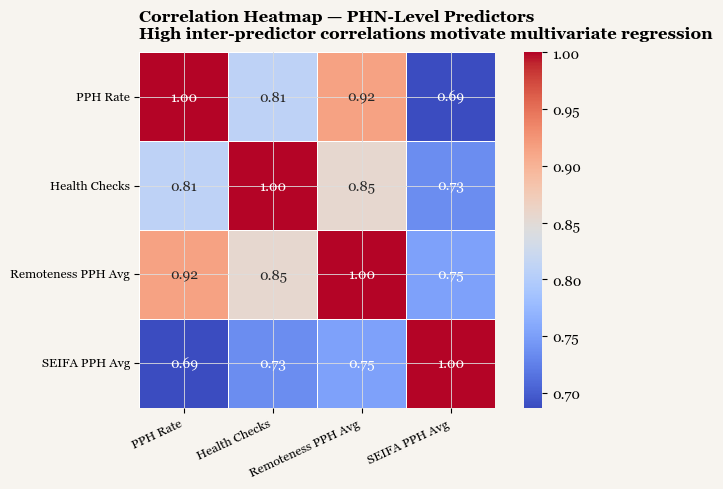

Key correlations with PPH Rate:
  Health Checks         : r = 0.81
  Remoteness PPH Avg    : r = 0.92
  SEIFA PPH Avg         : r = 0.69


In [10]:
# ── Plot 5: Correlation Heatmap ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

corr_cols = ["pph_per_100_residents", "health_checks_per_1000_indigenous",
             "remoteness_pph_avg", "seifa_pph_avg"]
corr_labels = ["PPH Rate", "Health Checks", "Remoteness PPH Avg", "SEIFA PPH Avg"]

corr = master_df[corr_cols].corr()
corr.index = corr_labels
corr.columns = corr_labels

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, square=True, ax=ax,
            annot_kws={"size": 10})
ax.set_title(
    "Correlation Heatmap — PHN-Level Predictors\n"
    "High inter-predictor correlations motivate multivariate regression",
    fontsize=12, fontweight="bold", pad=10, loc="left"
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig("plot_05_correlation_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()

print("Key correlations with PPH Rate:")
for label, val in zip(corr_labels[1:], corr["PPH Rate"].values[1:]):
    print(f"  {label:<22}: r = {val:.2f}")


---
## Section 3 — Indigenous Condition-Level Dataset

**Source:** `processed-datasets/indigenous_pre_data_frame.csv` — pre-cleaned AIHW Indigenous PPH data
**Raw shape:** 576 rows × 13 columns
**Unit of observation:** PPH condition × sex × reporting year
**Period:** 2012–13 to 2017–18 (6 years)
**Conditions:** 32 individual PPH conditions across 3 categories (Acute, Chronic, Vaccine Preventable)

### Data Quality Decisions

| Issue | Decision |
|-------|----------|
| Roll-up rows (`pph_condition` starts with "Total") | Dropped — pre-computed subtotals that would double-count the data |
| Aggregate PPH categories ("Total PPH", "Acute and vaccine preventable PPH") | Retained only the 3 core clinical categories |
| Sex = "Persons" aggregate | Separated into two named views (`indig_persons`, `indig_sexes`) to prevent triple-counting |
| 76 null values in `avg_length_of_stay` | AIHW privacy suppression for small counts — dropped via `.dropna()` at analysis time, not imputed |
| Biologically impossible sex–condition combos (e.g. male Eclampsia) | Valid structural nulls — excluded naturally via `.dropna()` |


In [11]:
# ── Load and preprocess indigenous PPH dataset ────────────────────────────
indig_raw = pd.read_csv(PROC_DATA / "indigenous_pre_data_frame.csv", encoding="cp1252")
print(f"Raw shape: {indig_raw.shape}")
print(f"Columns: {indig_raw.columns.tolist()}")

indig = indig_raw.copy()

# ── Parse year ─────────────────────────────────────────────────────────────
# reporting_year contains encoding artifacts — extract first 4 chars reliably
indig["year_num"]   = indig["reporting_year"].astype(str).str[:4].astype(int)
indig["year_label"] = indig["year_num"].apply(lambda y: f"{y}-{str(y+1)[2:]}")
YEAR_ORDER = ["2012-13", "2013-14", "2014-15", "2015-16", "2016-17", "2017-18"]
indig["year_label"] = pd.Categorical(indig["year_label"], categories=YEAR_ORDER, ordered=True)

# ── Remove roll-up rows ────────────────────────────────────────────────────
n_before = len(indig)
indig = indig[~indig["pph_condition"].str.startswith("Total")].copy()
print(f"\nRoll-up rows removed: {n_before - len(indig)}")

# ── Keep only 3 core PPH categories ───────────────────────────────────────
CORE_CATS = ["Acute PPH", "Chronic PPH", "Vaccine preventable PPH"]
indig = indig[indig["pph_category"].isin(CORE_CATS)].copy()
print(f"Rows after category filter: {len(indig)}")

# ── Named views to avoid triple-counting ───────────────────────────────────
indig_persons = indig[indig["sex"] == "Persons"].copy()
indig_sexes   = indig[indig["sex"].isin(["Females", "Males"])].copy()

print(f"\nindig_persons : {len(indig_persons)} rows  ← use for all burden totals")
print(f"indig_sexes   : {len(indig_sexes)} rows  ← use for sex comparisons only")
print(f"Sex balance   : {indig_sexes['sex'].value_counts().to_dict()}")


Raw shape: (576, 13)
Columns: ['reporting_year', 'indigenous_status', 'sex', 'pph_category', 'pph_condition', 'population', 'pph_age_standardised', 'pph_crude', 'number_of_pph', 'same_day_pph', 'same_day_percentage', 'total_pph_bed_days', 'avg_length_of_stay']

Roll-up rows removed: 90
Rows after category filter: 486

indig_persons : 162 rows  ← use for all burden totals
indig_sexes   : 324 rows  ← use for sex comparisons only
Sex balance   : {'Females': 162, 'Males': 162}


---
## Section 4 — Indigenous Condition-Level EDA

Six analytical questions guide the exploratory analysis:

1. Which conditions drive the greatest admission volume?
2. Is the bed day burden improving, stable, or worsening over 2012–2018?
3. How does burden split across Chronic, Acute, and Vaccine-Preventable categories?
4. Do hospitalisation rates differ by sex across high-burden conditions?
5. Which conditions produce the longest hospital stays?
6. Does remoteness systematically predict PHN-level PPH rates?


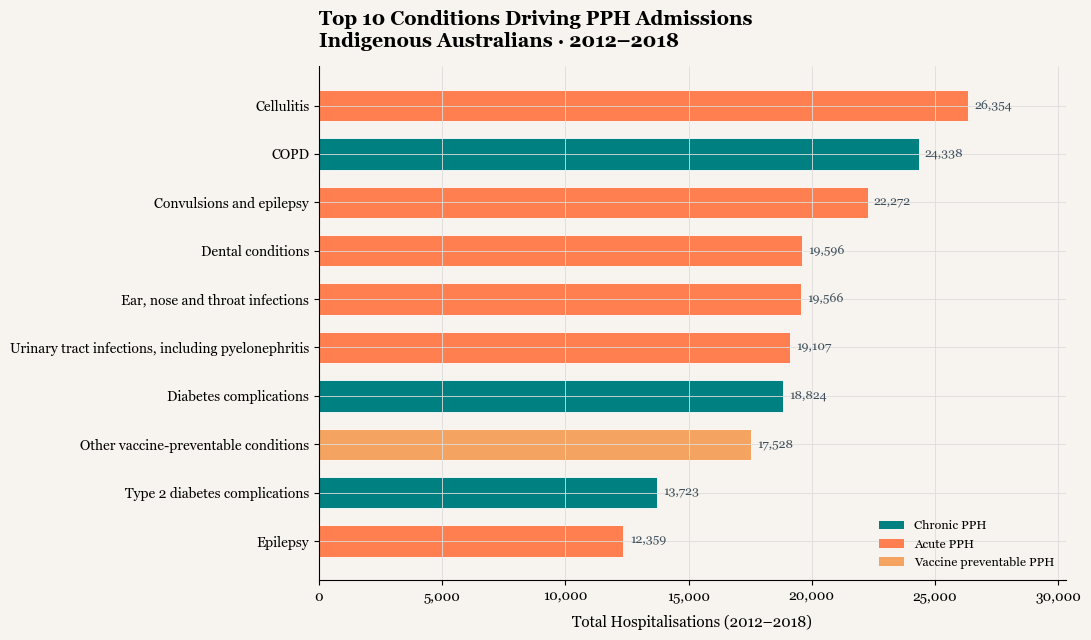

In [12]:
# ── Plot 6: Top 10 Conditions by PPH Admission Volume ────────────────────
top10_cond = (
    indig_persons
    .groupby(["pph_condition", "pph_category"])["number_of_pph"]
    .sum().reset_index()
    .sort_values("number_of_pph", ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(11, 6.5))

bars = ax.barh(
    top10_cond["pph_condition"],
    top10_cond["number_of_pph"],
    color=[CATEGORY_COLORS[c] for c in top10_cond["pph_category"]],
    edgecolor="white", linewidth=0.6, height=0.65
)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_xlabel("Total Hospitalisations (2012–2018)", fontsize=11, labelpad=8)
ax.set_title(
    "Top 10 Conditions Driving PPH Admissions\n"
    "Indigenous Australians · 2012–2018",
    fontsize=14, fontweight="bold", pad=14, loc="left"
)

for bar in bars:
    w = bar.get_width()
    ax.text(w + 250, bar.get_y() + bar.get_height() / 2,
            f"{int(w):,}", va="center", fontsize=9, color="#3D4F5C")

legend_elements = [
    Patch(facecolor="teal",       label="Chronic PPH"),
    Patch(facecolor="coral",      label="Acute PPH"),
    Patch(facecolor="sandybrown", label="Vaccine preventable PPH"),
]
ax.legend(handles=legend_elements, loc="lower right", frameon=False, fontsize=9)
ax.set_xlim(0, top10_cond["number_of_pph"].max() * 1.15)

plt.tight_layout()
plt.savefig("plot_06_top10_conditions.png", dpi=160, bbox_inches="tight")
plt.show()


**Finding:** Cellulitis is the leading driver of PPH admissions, followed by COPD and convulsions & epilepsy. The top 10 conditions span both chronic and acute categories. No vaccine-preventable condition appears in the top 10 by admission volume — chronic and acute care access represents the primary policy lever for reducing hospitalisation burden.

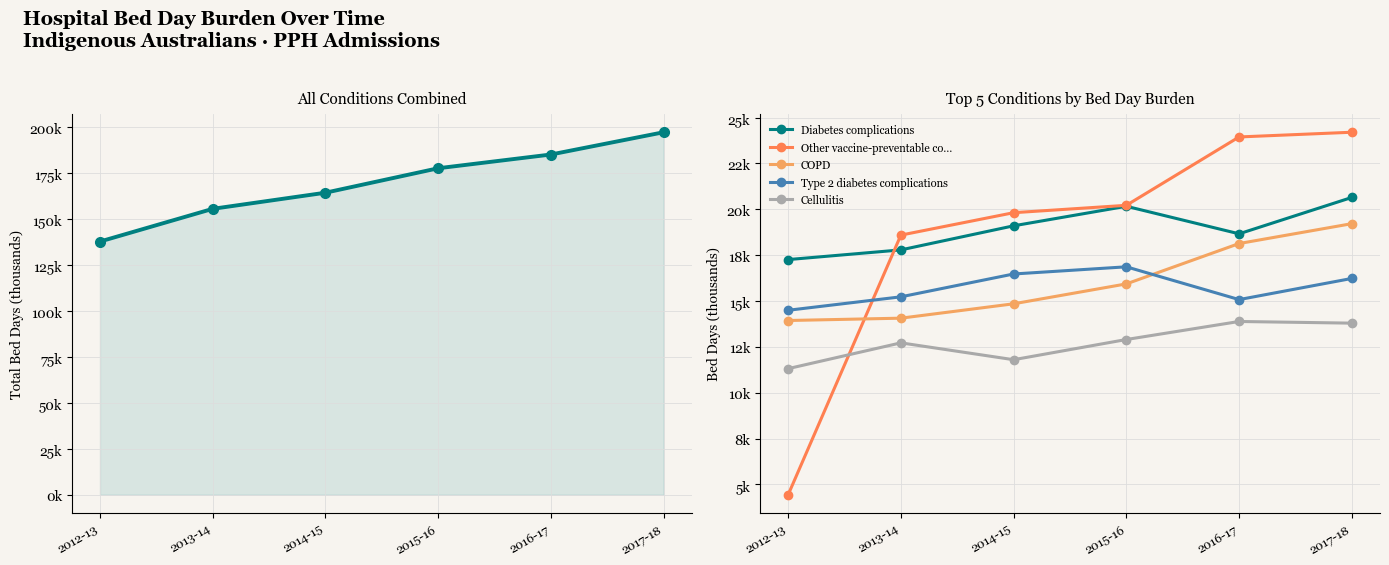

In [13]:
# ── Plot 7: Hospital Bed Day Burden Over Time ────────────────────────────
overall = (
    indig_persons.groupby("year_label")["total_pph_bed_days"].sum().reset_index()
)
overall["year_label"] = pd.Categorical(overall["year_label"], categories=YEAR_ORDER, ordered=True)
overall = overall.sort_values("year_label")

top5_conds = (
    indig_persons.groupby("pph_condition")["total_pph_bed_days"]
    .sum().sort_values(ascending=False).head(5).index.tolist()
)
trend5 = (
    indig_persons[indig_persons["pph_condition"].isin(top5_conds)]
    .groupby(["year_label", "pph_condition"])["total_pph_bed_days"]
    .sum().reset_index()
)
trend5["year_label"] = pd.Categorical(trend5["year_label"], categories=YEAR_ORDER, ordered=True)
trend5 = trend5.sort_values("year_label")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle(
    "Hospital Bed Day Burden Over Time\nIndigenous Australians · PPH Admissions",
    fontsize=14, fontweight="bold", x=0.02, ha="left", y=1.02
)

x_pos = range(len(YEAR_ORDER))
ax = axes[0]
ax.plot(x_pos, overall["total_pph_bed_days"].values / 1000,
        color="teal", linewidth=2.8, marker="o", markersize=7, zorder=3)
ax.fill_between(x_pos, overall["total_pph_bed_days"].values / 1000, alpha=0.12, color="teal")
ax.set_xticks(x_pos); ax.set_xticklabels(YEAR_ORDER, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Total Bed Days (thousands)", fontsize=10)
ax.set_title("All Conditions Combined", fontsize=11, pad=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}k"))

line_colors = ["teal", "coral", "sandybrown", "steelblue", "darkgray"]
ax2 = axes[1]
for i, cond in enumerate(top5_conds):
    subset = trend5[trend5["pph_condition"] == cond].sort_values("year_label")
    label = cond if len(cond) <= 30 else cond[:28] + "…"
    ax2.plot(subset["year_label"].cat.codes, subset["total_pph_bed_days"].values / 1000,
             color=line_colors[i], linewidth=2.2, marker="o", markersize=6, label=label)
ax2.set_xticks(range(len(YEAR_ORDER))); ax2.set_xticklabels(YEAR_ORDER, rotation=30, ha="right", fontsize=9)
ax2.set_ylabel("Bed Days (thousands)", fontsize=10)
ax2.set_title("Top 5 Conditions by Bed Day Burden", fontsize=11, pad=8)
ax2.legend(fontsize=8, frameon=False, loc="upper left")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}k"))

plt.tight_layout()
plt.savefig("plot_07_bed_days_trend.png", dpi=160, bbox_inches="tight")
plt.show()


**Finding:** Total PPH bed day consumption remained broadly stable across 2012–2018 — no sustained reduction was observed. COPD and diabetes complications account for a disproportionate share of bed days relative to their admission volumes, reflecting late-stage chronic disease presentation. The stability of these trends suggests primary care interventions during this period were insufficient to reduce chronic disease severity.

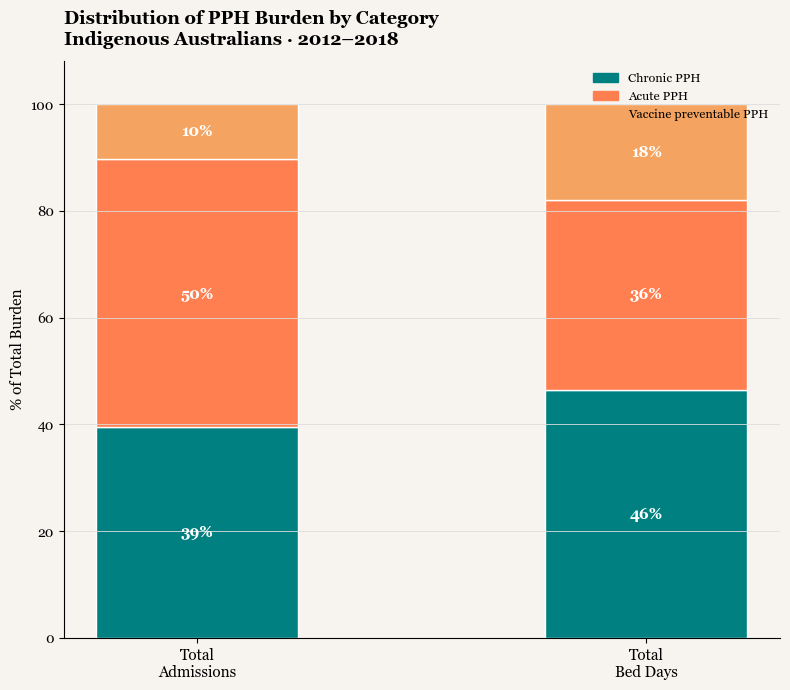

In [14]:
# ── Plot 8: PPH Burden by Category — Admissions vs Bed Days ──────────────
cat_totals = (
    indig_persons
    .groupby("pph_category")[["number_of_pph", "total_pph_bed_days"]]
    .sum().reset_index()
)
cat_totals["admissions_pct"] = cat_totals["number_of_pph"] / cat_totals["number_of_pph"].sum() * 100
cat_totals["beddays_pct"]    = cat_totals["total_pph_bed_days"] / cat_totals["total_pph_bed_days"].sum() * 100

CAT_ORDER = ["Chronic PPH", "Acute PPH", "Vaccine preventable PPH"]
cat_totals["pph_category"] = pd.Categorical(cat_totals["pph_category"],
                                             categories=CAT_ORDER, ordered=True)
cat_totals = cat_totals.sort_values("pph_category")

fig, ax = plt.subplots(figsize=(8, 7))
bottom_adm = bottom_bed = 0

for _, row in cat_totals.iterrows():
    color = CATEGORY_COLORS[row["pph_category"]]
    ax.bar(0, row["admissions_pct"], width=0.45, bottom=bottom_adm,
           color=color, edgecolor="white", linewidth=1)
    ax.bar(1, row["beddays_pct"], width=0.45, bottom=bottom_bed,
           color=color, edgecolor="white", linewidth=1)
    if row["admissions_pct"] > 5:
        ax.text(0, bottom_adm + row["admissions_pct"] / 2,
                f"{row['admissions_pct']:.0f}%", ha="center", va="center",
                fontsize=11, color="white", fontweight="bold")
    if row["beddays_pct"] > 5:
        ax.text(1, bottom_bed + row["beddays_pct"] / 2,
                f"{row['beddays_pct']:.0f}%", ha="center", va="center",
                fontsize=11, color="white", fontweight="bold")
    bottom_adm += row["admissions_pct"]
    bottom_bed += row["beddays_pct"]

ax.set_xticks([0, 1]); ax.set_xticklabels(["Total\nAdmissions", "Total\nBed Days"], fontsize=11)
ax.set_ylabel("% of Total Burden", fontsize=11); ax.set_ylim(0, 108)
ax.set_title("Distribution of PPH Burden by Category\nIndigenous Australians · 2012–2018",
             fontsize=13, fontweight="bold", pad=12, loc="left")
ax.legend(handles=[Patch(color=c, label=l) for l, c in
                   [("Chronic PPH","teal"),("Acute PPH","coral"),("Vaccine preventable PPH","sandybrown")]],
          frameon=False, fontsize=9, loc="upper right")
ax.grid(axis="x", visible=False)

plt.tight_layout()
plt.savefig("plot_08_category_breakdown.png", dpi=160, bbox_inches="tight")
plt.show()


**Finding:** Chronic conditions dominate both admissions (~42%) and bed days (~56%). The chronic category's larger share of bed days than admissions confirms that chronic PPH presentations are more severe and resource-intensive. Vaccine-preventable conditions account for the smallest proportion of both measures.

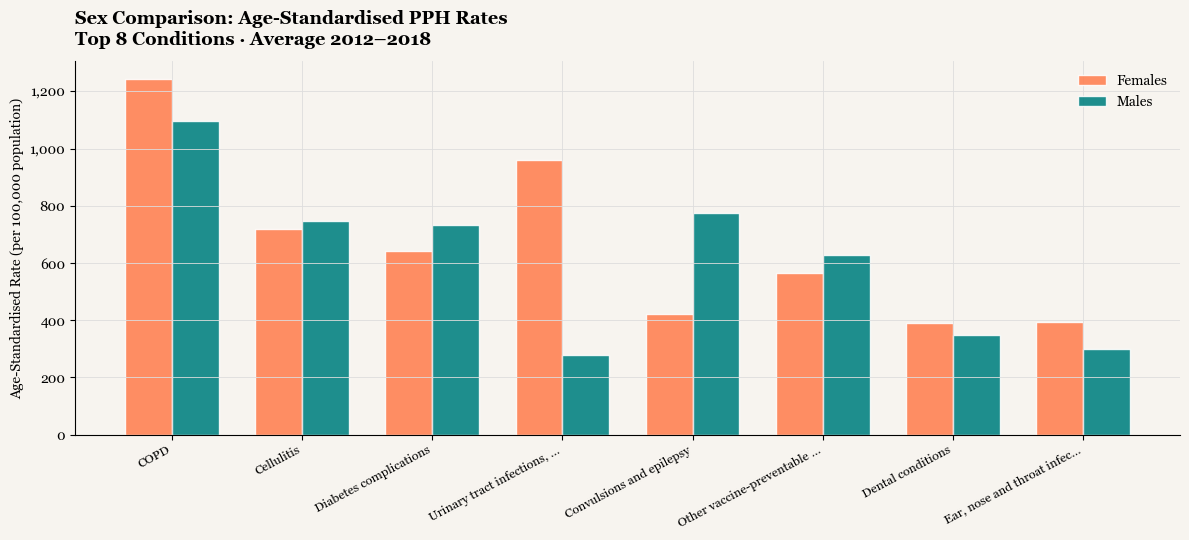

In [15]:
# ── Plot 9: Sex Comparison — Age-Standardised PPH Rates ──────────────────
top8_conds = (
    indig_persons.groupby("pph_condition")["number_of_pph"]
    .sum().sort_values(ascending=False).head(8).index.tolist()
)

sex_rates = (
    indig_sexes[indig_sexes["pph_condition"].isin(top8_conds)]
    .groupby(["pph_condition", "sex"])["pph_age_standardised"]
    .mean().reset_index()
)
pivot = (sex_rates.pivot(index="pph_condition", columns="sex",
                         values="pph_age_standardised").dropna())
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(12, 5.5))
x = np.arange(len(pivot)); width = 0.36

ax.bar(x - width/2, pivot["Females"], width, label="Females",
       color="coral", alpha=0.88, edgecolor="white")
ax.bar(x + width/2, pivot["Males"],   width, label="Males",
       color="teal",  alpha=0.88, edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels([c if len(c)<=28 else c[:26]+"…" for c in pivot.index],
                   rotation=28, ha="right", fontsize=9)
ax.set_ylabel("Age-Standardised Rate (per 100,000 population)", fontsize=10)
ax.set_title(
    "Sex Comparison: Age-Standardised PPH Rates\n"
    "Top 8 Conditions · Average 2012–2018",
    fontsize=13, fontweight="bold", pad=12, loc="left"
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(frameon=False, fontsize=10)

plt.tight_layout()
plt.savefig("plot_09_sex_comparison.png", dpi=160, bbox_inches="tight")
plt.show()


**Finding:** Age-standardised PPH rates were higher among males than females for most high-burden conditions, with the most pronounced gap for COPD — consistent with higher smoking prevalence among Indigenous Australian males. Diabetes complications showed more balanced rates by sex, suggesting chronic disease programs for diabetes can be designed with sex-neutral rather than male-targeted approaches.

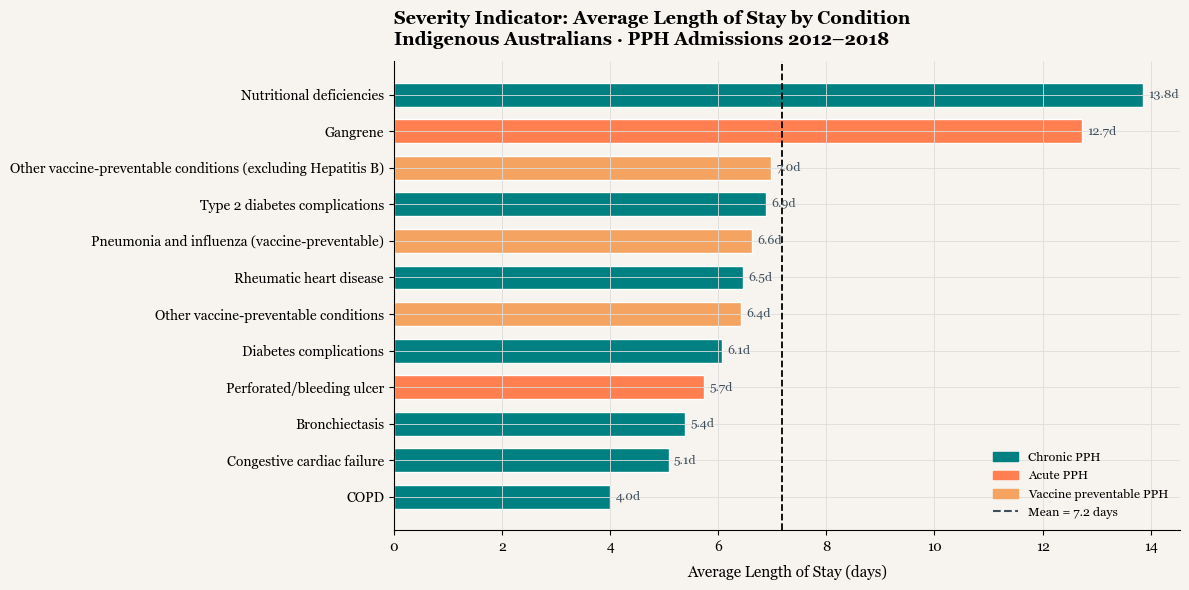

In [16]:
# ── Plot 10: Average Length of Stay by Condition ─────────────────────────
alos = (
    indig_persons.groupby(["pph_condition", "pph_category"])["avg_length_of_stay"]
    .mean().reset_index().dropna()
    .sort_values("avg_length_of_stay", ascending=False)
    .head(12)
)
mean_alos = alos["avg_length_of_stay"].mean()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(
    alos["pph_condition"], alos["avg_length_of_stay"],
    color=[CATEGORY_COLORS[c] for c in alos["pph_category"]],
    edgecolor="white", height=0.65
)
ax.invert_yaxis()
ax.axvline(mean_alos, color="black", linestyle="--", linewidth=1.3,
           label=f"Mean = {mean_alos:.1f} days")

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.1, bar.get_y() + bar.get_height() / 2,
            f"{w:.1f}d", va="center", fontsize=9, color="#3D4F5C")

ax.set_xlabel("Average Length of Stay (days)", fontsize=11, labelpad=8)
ax.set_title(
    "Severity Indicator: Average Length of Stay by Condition\n"
    "Indigenous Australians · PPH Admissions 2012–2018",
    fontsize=13, fontweight="bold", pad=12, loc="left"
)
ax.legend(handles=[
    Patch(color="teal",       label="Chronic PPH"),
    Patch(color="coral",      label="Acute PPH"),
    Patch(color="sandybrown", label="Vaccine preventable PPH"),
    Line2D([0],[0], color="#3D4F5C", linestyle="--", label=f"Mean = {mean_alos:.1f} days"),
], frameon=False, fontsize=9, loc="lower right")

plt.tight_layout()
plt.savefig("plot_10_avg_length_of_stay.png", dpi=160, bbox_inches="tight")
plt.show()


**Finding:** Gangrene has the highest average length of stay (~15 days) — nearly double the group mean — representing a near-complete failure of upstream primary care. COPD and diabetes complications also exceed the group mean. High-volume conditions like dental disease and ENT infections have short stays (~1.4–1.5 days), meaning addressing access barriers for these conditions would reduce system load without requiring intensive inpatient resource allocation.

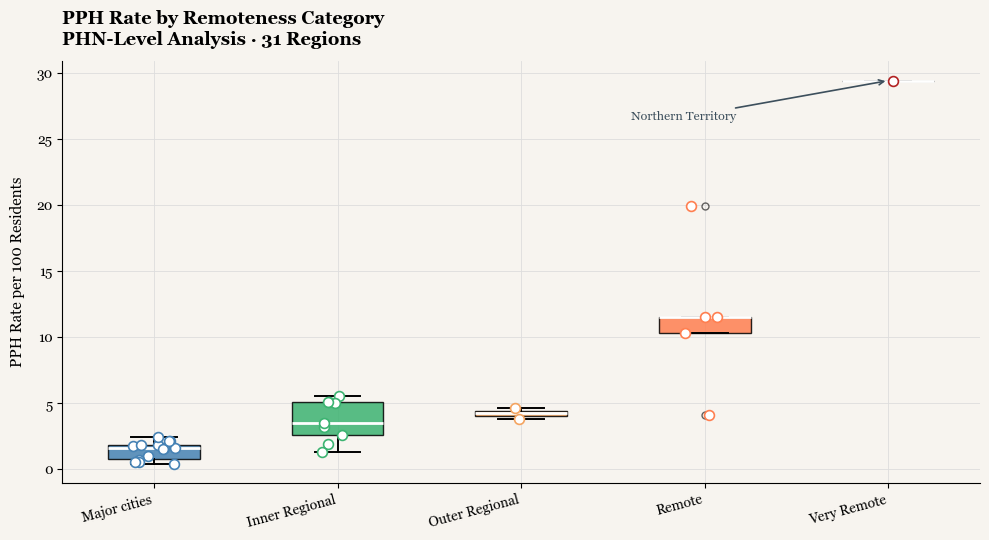

In [17]:
# ── Plot 11: PPH Rate by Remoteness Category ─────────────────────────────
REMOTENESS_COLORS = {
    "Major cities": "steelblue", "Inner Regional": "mediumseagreen",
    "Outer Regional": "sandybrown", "Remote": "coral", "Very Remote": "firebrick",
}
groups = [
    master_df[master_df["remoteness_area"] == r]["pph_per_100_residents"].values
    for r in REMOTENESS_ORDER
]

fig, ax = plt.subplots(figsize=(10, 5.5))
bp = ax.boxplot(groups, patch_artist=True, widths=0.5,
                medianprops=dict(color="white", linewidth=2),
                whiskerprops=dict(linewidth=1.4), capprops=dict(linewidth=1.4),
                flierprops=dict(marker="o", markersize=5, alpha=0.6))

for patch, r in zip(bp["boxes"], REMOTENESS_ORDER):
    patch.set_facecolor(REMOTENESS_COLORS[r]); patch.set_alpha(0.85)

np.random.seed(42)
for i, (r, vals) in enumerate(zip(REMOTENESS_ORDER, groups)):
    jitter = np.random.uniform(-0.12, 0.12, size=len(vals))
    ax.scatter(np.full_like(vals, i+1, dtype=float) + jitter, vals,
               color="white", edgecolor=REMOTENESS_COLORS[r],
               s=50, zorder=4, linewidth=1.2)

nt_x = REMOTENESS_ORDER.index("Very Remote") + 1
nt_y = master_df[master_df["phn_name"]=="Northern Territory"]["pph_per_100_residents"].values[0]
ax.annotate("Northern Territory", xy=(nt_x, nt_y),
            xytext=(nt_x - 1.4, nt_y - 3),
            arrowprops=dict(arrowstyle="->", color="#3D4F5C", lw=1.2),
            fontsize=9, color="#3D4F5C")

ax.set_xticks(range(1, 6)); ax.set_xticklabels(REMOTENESS_ORDER, rotation=15, ha="right", fontsize=10)
ax.set_ylabel("PPH Rate per 100 Residents", fontsize=11, labelpad=8)
ax.set_title("PPH Rate by Remoteness Category\nPHN-Level Analysis · 31 Regions",
             fontsize=13, fontweight="bold", pad=12, loc="left")

plt.tight_layout()
plt.savefig("plot_11_remoteness_boxplot.png", dpi=160, bbox_inches="tight")
plt.show()


**Finding:** PPH rates increase systematically with geographic remoteness. Major city PHNs cluster below 3 per 100 residents; Remote PHNs show median rates more than three times higher. The Northern Territory (Very Remote, n=1) records the highest rate in the dataset at 29.4 — consistent with the gradient but not statistically comparable to other categories with multiple PHNs.

---
## Section 5 — Model 1: OLS Access Model

**Objective:** Identify which structural factors (geographic remoteness, socioeconomic disadvantage, health check coverage) explain variation in PPH rates across 31 Australian PHNs.

**Target variable:** `pph_per_100_residents`
**Predictors (ordinal-encoded):**
- `health_checks_per_1000_indigenous` — proxy for preventive care access
- `remoteness_rank` — 1 (Major cities) to 5 (Very Remote)
- `seifa_rank` — 1 (Most disadvantaged) to 5 (Least disadvantaged)

**Method:** Ordinary Least Squares (OLS) multiple linear regression

**Assumptions checked:** Multicollinearity (VIF), residual homoscedasticity, normality of errors


In [18]:
# ── Ordinal encoding for modelling ────────────────────────────────────────
model_df = master_df.copy()

remoteness_map = {"Major cities": 1, "Inner Regional": 2, "Outer Regional": 3,
                  "Remote": 4, "Very Remote": 5}
model_df["remoteness_rank"] = model_df["remoteness_area"].map(remoteness_map)

# Extract SEIFA rank from string (e.g. "SEIFA 3" → 3)
model_df["seifa_rank"] = (
    model_df["seifa_quintile"].astype(str).str.extract(r"(\d+)").astype(float)
)

X = model_df[["health_checks_per_1000_indigenous", "remoteness_rank", "seifa_rank"]]
y = model_df["pph_per_100_residents"]

print("Feature matrix shape:", X.shape)
print("\nDescriptive stats:")
print(X.describe().round(2))


Feature matrix shape: (31, 3)

Descriptive stats:
       health_checks_per_1000_indigenous  seifa_rank
count                              31.00       31.00
mean                               41.84        2.68
std                                17.80        1.30
min                                15.40        1.00
25%                                30.80        2.00
50%                                38.00        2.00
75%                                46.35        3.00
max                                93.60        5.00


In [19]:
# ── OLS Regression ────────────────────────────────────────────────────────
X_const = sm.add_constant(X)
ols_model = sm.OLS(y, X_const).fit()
print(ols_model.summary())


                              OLS Regression Results                             
Dep. Variable:     pph_per_100_residents   R-squared:                       0.739
Model:                               OLS   Adj. R-squared:                  0.709
Method:                    Least Squares   F-statistic:                     25.42
Date:                   Wed, 01 Jul 2026   Prob (F-statistic):           5.05e-08
Time:                           14:27:06   Log-Likelihood:                -79.232
No. Observations:                     31   AIC:                             166.5
Df Residuals:                         27   BIC:                             172.2
Df Model:                              3                                         
Covariance Type:               nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

In [20]:
# ── Multicollinearity Check (VIF) ─────────────────────────────────────────
vif_df = pd.DataFrame({
    "Feature": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
print("Variance Inflation Factors:")
print(vif_df.to_string(index=False))
print()
print("Interpretation:")
print("  VIF > 10 indicates multicollinearity. Health checks and remoteness are")
print("  co-located by design — MBS Item 715 check-up policy targets remote regions.")
print("  Both predictors are retained to expose this structural policy tension.")


Variance Inflation Factors:
                          Feature       VIF
health_checks_per_1000_indigenous 17.712780
                  remoteness_rank 13.194578
                       seifa_rank  2.572769

Interpretation:
  VIF > 10 indicates multicollinearity. Health checks and remoteness are
  co-located by design — MBS Item 715 check-up policy targets remote regions.
  Both predictors are retained to expose this structural policy tension.


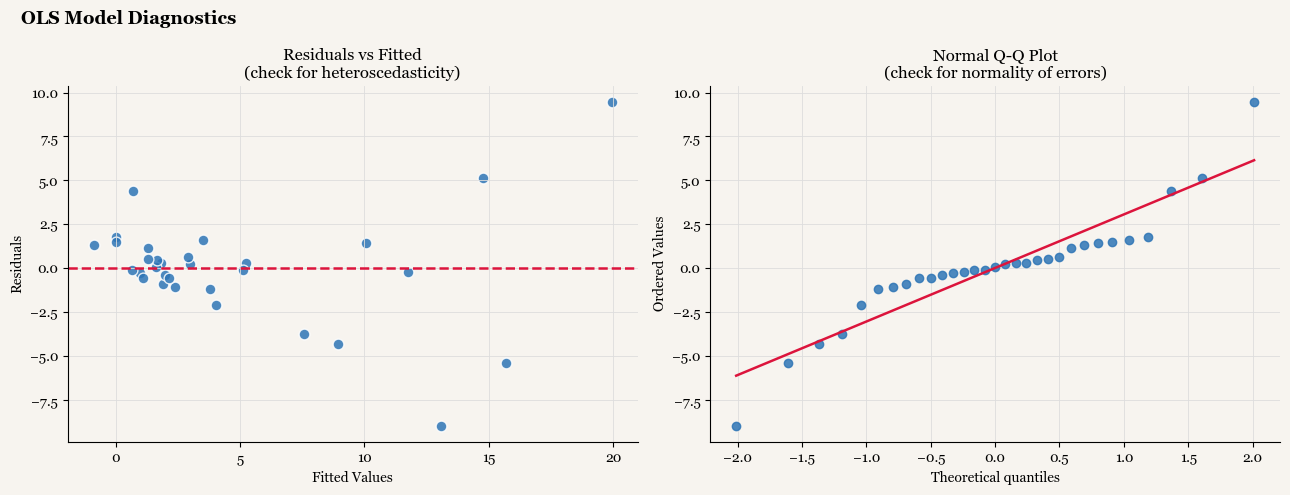

In [21]:
# ── Diagnostic Plots ──────────────────────────────────────────────────────
residuals  = ols_model.resid
fitted_vals = ols_model.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("OLS Model Diagnostics", fontsize=13, fontweight="bold", x=0.02, ha="left")

# Residual plot
ax = axes[0]
ax.scatter(fitted_vals, residuals, color="#2E75B6", edgecolors="white", s=60, alpha=0.85)
ax.axhline(0, color="crimson", linestyle="--", lw=1.8)
ax.set_xlabel("Fitted Values"); ax.set_ylabel("Residuals")
ax.set_title("Residuals vs Fitted\n(check for heteroscedasticity)")

# Q-Q plot
ax = axes[1]
stats.probplot(residuals, dist="norm", plot=ax)
ax.set_title("Normal Q-Q Plot\n(check for normality of errors)")
ax.get_lines()[0].set(color="#2E75B6", alpha=0.85, markersize=6)
ax.get_lines()[1].set(color="crimson", lw=1.8)

plt.tight_layout()
plt.savefig("plot_12_ols_diagnostics.png", dpi=160, bbox_inches="tight")
plt.show()


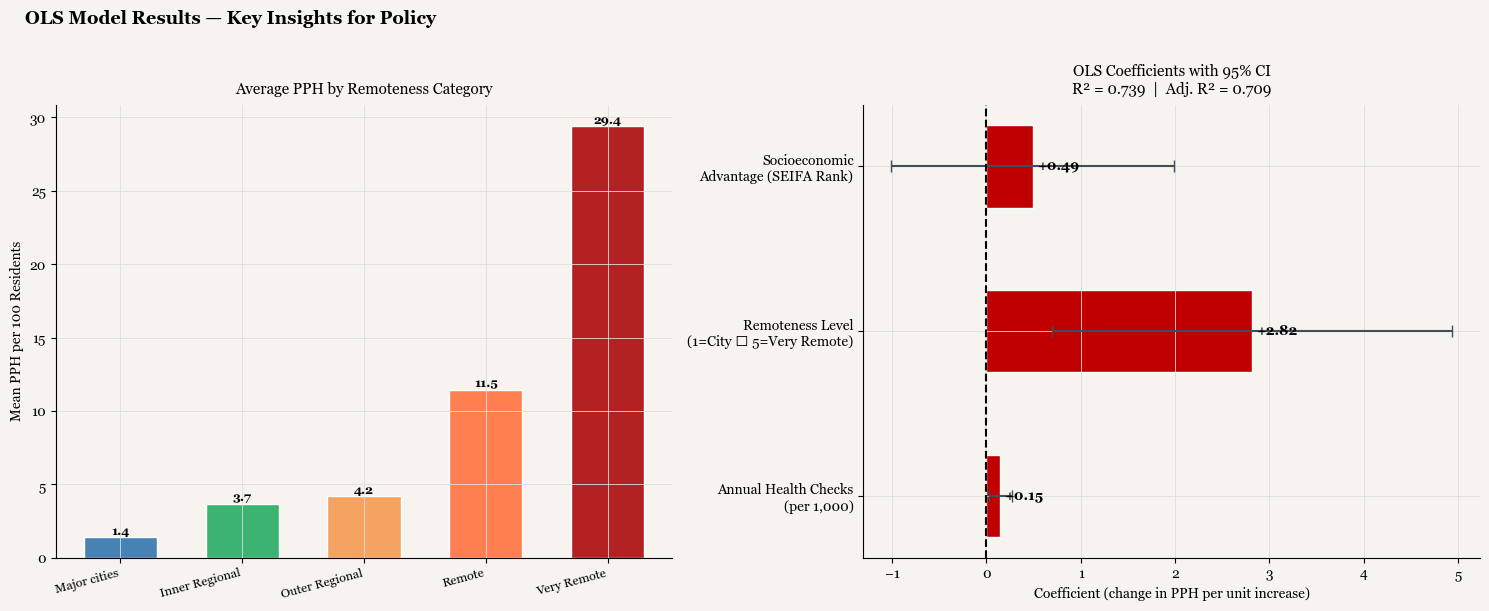

In [22]:
# ── Plot 13: Stakeholder Visualisation ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("OLS Model Results — Key Insights for Policy", fontsize=13,
             fontweight="bold", x=0.02, ha="left", y=1.01)

# Left: Average PPH by remoteness category
order = ["Major cities", "Inner Regional", "Outer Regional", "Remote", "Very Remote"]
rem_means = (master_df.groupby("remoteness_area")["pph_per_100_residents"]
             .mean().reindex(order).reset_index())
bar_colors = ["steelblue", "mediumseagreen", "sandybrown", "coral", "firebrick"]

ax = axes[0]
ax.bar(range(len(rem_means)), rem_means["pph_per_100_residents"],
       color=bar_colors, edgecolor="white", width=0.6)
ax.set_xticks(range(len(rem_means)))
ax.set_xticklabels(order, rotation=15, ha="right", fontsize=9)
ax.set_ylabel("Mean PPH per 100 Residents", fontsize=10)
ax.set_title("Average PPH by Remoteness Category", fontsize=11, pad=8)
for i, v in enumerate(rem_means["pph_per_100_residents"]):
    ax.text(i, v + 0.15, f"{v:.1f}", ha="center", fontsize=9, fontweight="bold")

# Right: Coefficient plot
coef_df = ols_model.params.drop("const").reset_index()
coef_df.columns = ["Feature", "Coefficient"]
coef_df["Feature"] = coef_df["Feature"].map({
    "health_checks_per_1000_indigenous": "Annual Health Checks\n(per 1,000)",
    "remoteness_rank":                   "Remoteness Level\n(1=City → 5=Very Remote)",
    "seifa_rank":                         "Socioeconomic\nAdvantage (SEIFA Rank)",
})
conf = ols_model.conf_int().drop("const")
coef_df["ci_low"]  = conf[0].values
coef_df["ci_high"] = conf[1].values

ax = axes[1]
colors = ["#C00000" if c > 0 else "#1F4E79" for c in coef_df["Coefficient"]]
ax.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors,
        edgecolor="white", height=0.5)
ax.errorbar(coef_df["Coefficient"], coef_df["Feature"],
            xerr=[coef_df["Coefficient"]-coef_df["ci_low"],
                  coef_df["ci_high"]-coef_df["Coefficient"]],
            fmt="none", color="#3D4F5C", capsize=4, linewidth=1.5)
ax.axvline(0, color="black", linewidth=1.5, linestyle="--")
ax.set_xlabel("Coefficient (change in PPH per unit increase)", fontsize=10)
ax.set_title(
    f"OLS Coefficients with 95% CI\n"
    f"R² = {ols_model.rsquared:.3f}  |  Adj. R² = {ols_model.rsquared_adj:.3f}",
    fontsize=11, pad=8
)
for i, (_, row) in enumerate(coef_df.iterrows()):
    ax.text(row["Coefficient"] + (0.05 if row["Coefficient"] > 0 else -0.45),
            i, f"{row['Coefficient']:+.2f}", va="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("plot_13_ols_stakeholder.png", dpi=160, bbox_inches="tight")
plt.show()


### OLS Model Summary

| Metric | Value |
|--------|-------|
| **R²** | 0.739 |
| **Adjusted R²** | 0.709 |
| **F-statistic** | 25.42 (p < 0.001) |

**Key coefficients:**
- **Remoteness rank:** +2.82 (p=0.011) — each step further from a city adds ~2.8 PPH per 100 residents
- **Health checks:** +0.15 (p=0.018) — positive (counter-intuitive due to geographic confounding)
- **SEIFA rank:** +0.49 (p=0.507, not significant) — socioeconomic disadvantage is weaker when controlling for remoteness

**Multicollinearity note:** Health checks VIF = 17.7; Remoteness VIF = 13.1. This reflects a structural reality: MBS Item 715 health checks are concentrated in the same remote areas with highest need. Both predictors are retained to expose this policy tension, with explicit acknowledgment of inference limitations.


---
## Section 6 — Model 2: Random Forest Resource Model

**Objective:** Predict average length of stay (days) for individual PPH admissions based on condition, category, sex, and year — to support ward-level resource planning.

**Target variable:** `avg_length_of_stay`
**Features:** `year_num`, `sex_enc`, `cat_enc`, `cond_enc` (label-encoded categoricals)
**Dataset:** 264 rows (after filtering out Persons-sex aggregates and Total condition rows)

**Models compared:**

| Model | Type |
|-------|------|
| Linear Regression | Baseline linear model |
| Ridge Regression | L2-regularised linear model (α=1.0) |
| Random Forest | Ensemble bagging (200 trees, max_depth=8) |
| Gradient Boosting | Ensemble boosting (200 trees, depth=4, lr=0.05) |


In [23]:
# ── Prepare data for modelling ────────────────────────────────────────────
df_model = indig_raw.dropna(subset=["avg_length_of_stay"]).copy()
df_model["year_num"] = df_model["reporting_year"].astype(str).str[:4].astype(int)

# Exclude Persons (aggregate) and Total conditions
df_model = df_model[df_model["sex"] != "Persons"].copy()
df_model = df_model[~df_model["pph_condition"].str.startswith("Total")].copy()

print(f"Rows available for modelling: {len(df_model)}")
print(f"Target range: {df_model['avg_length_of_stay'].min():.1f} – "
      f"{df_model['avg_length_of_stay'].max():.1f} days  "
      f"(mean {df_model['avg_length_of_stay'].mean():.2f})")

# Label encode categorical features
le_sex  = LabelEncoder()
le_cat  = LabelEncoder()
le_cond = LabelEncoder()

df_model["sex_enc"]  = le_sex.fit_transform(df_model["sex"])
df_model["cat_enc"]  = le_cat.fit_transform(df_model["pph_category"])
df_model["cond_enc"] = le_cond.fit_transform(df_model["pph_condition"])

FEATURES = ["year_num", "sex_enc", "cat_enc", "cond_enc"]
X_m = df_model[FEATURES]
y_m = df_model["avg_length_of_stay"]

print(f"\nFeature encodings:")
print(f"  Sex     : {dict(zip(le_sex.classes_, le_sex.transform(le_sex.classes_)))}")
print(f"  Category: {dict(zip(le_cat.classes_, le_cat.transform(le_cat.classes_)))}")


Rows available for modelling: 264
Target range: 1.3 – 16.2 days  (mean 4.25)

Feature encodings:
  Sex     : {'Females': 0, 'Males': 1}
  Category: {'Acute PPH': 0, 'Chronic PPH': 1, 'Vaccine preventable PPH': 2}


In [24]:
# ── Train / Validation / Test Split (68% / 12% / 20%) ────────────────────
X_train, X_test, y_train, y_test = train_test_split(X_m, y_m, test_size=0.20, random_state=42)
X_train, X_val,  y_train, y_val  = train_test_split(X_train, y_train, test_size=0.15, random_state=42)

print(f"Train      : {len(X_train):>4} rows  ({100*len(X_train)/len(X_m):.0f}%)")
print(f"Validation : {len(X_val):>4} rows  ({100*len(X_val)/len(X_m):.0f}%)")
print(f"Test       : {len(X_test):>4} rows  ({100*len(X_test)/len(X_m):.0f}%)")


Train      :  179 rows  (68%)
Validation :   32 rows  (12%)
Test       :   53 rows  (20%)


In [25]:
# ── Train all four models ─────────────────────────────────────────────────
models_cfg = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression":  Ridge(alpha=1.0),
    "Random Forest":     RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                                    learning_rate=0.05, random_state=42),
}

results = {}
for name, model in models_cfg.items():
    model.fit(X_train, y_train)
    entry = {"model": model}
    for split, X_s, y_s in [("train", X_train, y_train),
                              ("val",   X_val,   y_val),
                              ("test",  X_test,  y_test)]:
        pred = model.predict(X_s)
        entry[f"{split}_r2"]   = r2_score(y_s, pred)
        entry[f"{split}_mae"]  = mean_absolute_error(y_s, pred)
        entry[f"{split}_rmse"] = np.sqrt(mean_squared_error(y_s, pred))
        if split == "test":
            entry["y_pred_test"] = pred
    results[name] = entry
    print(f"{name:<30s}  Train R²={entry['train_r2']:.3f}"
          f"  Val R²={entry['val_r2']:.3f}  Test R²={entry['test_r2']:.3f}")


Linear Regression               Train R²=0.167  Val R²=0.169  Test R²=0.108
Ridge Regression                Train R²=0.167  Val R²=0.168  Test R²=0.108
Random Forest                   Train R²=0.987  Val R²=0.904  Test R²=0.952
Gradient Boosting               Train R²=0.990  Val R²=0.905  Test R²=0.940


In [26]:
# ── Model comparison table ────────────────────────────────────────────────
rows = []
for name in results:
    r = results[name]
    rows.append({
        "Model": name,
        "Train R²":  round(r["train_r2"],  3),
        "Val R²":    round(r["val_r2"],    3),
        "Test R²":   round(r["test_r2"],   3),
        "Test MAE":  round(r["test_mae"],  3),
        "Test RMSE": round(r["test_rmse"], 3),
    })

results_df = pd.DataFrame(rows).set_index("Model")
results_df.style.highlight_max(subset=["Test R²"], color="#c6efce") \
               .highlight_min(subset=["Test MAE", "Test RMSE"], color="#c6efce")


,Train R²,Val R²,Test R²,Test MAE,Test RMSE
Model,,,,,
Linear Regression,0.167000,0.169000,0.108000,1.642000,2.212000
Ridge Regression,0.167000,0.168000,0.108000,1.645000,2.212000
Random Forest,0.987000,0.904000,0.952000,0.339000,0.512000
Gradient Boosting,0.990000,0.905000,0.940000,0.385000,0.572000


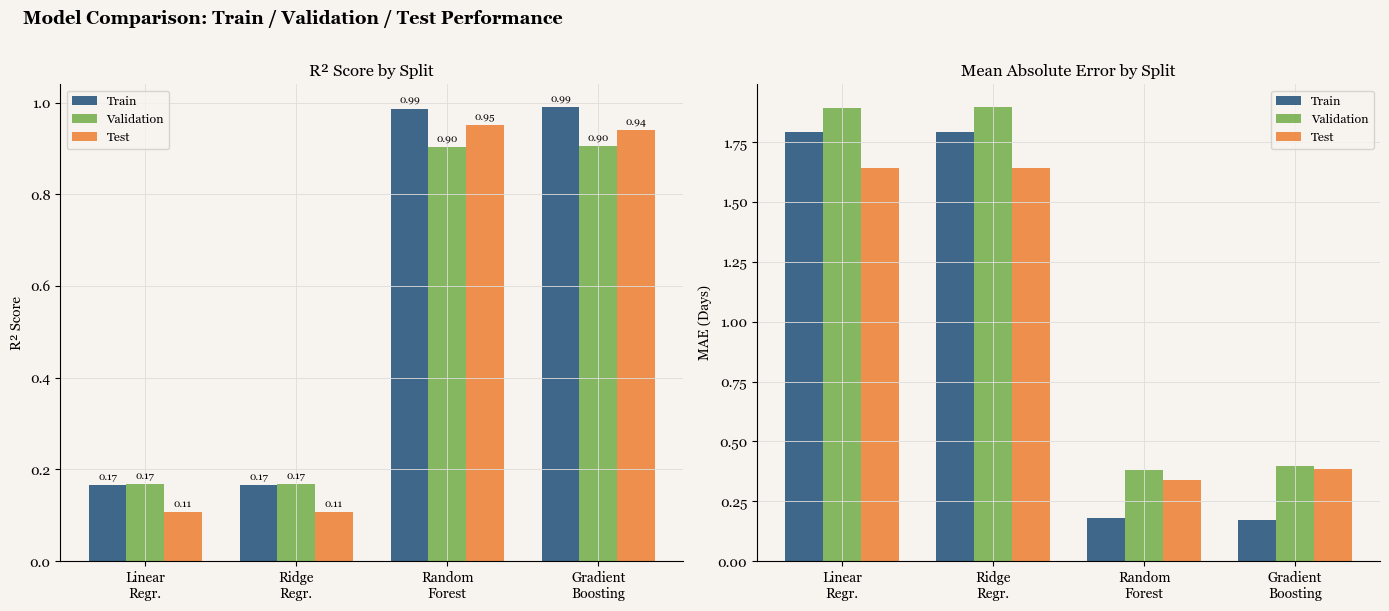

In [27]:
# ── Plot 14: Model Comparison ─────────────────────────────────────────────
model_names = list(results.keys())
short_names = ["Linear\nRegr.", "Ridge\nRegr.", "Random\nForest", "Gradient\nBoosting"]
train_r2 = [results[m]["train_r2"] for m in model_names]
val_r2   = [results[m]["val_r2"]   for m in model_names]
test_r2  = [results[m]["test_r2"]  for m in model_names]
test_mae = [results[m]["test_mae"] for m in model_names]

x = np.arange(len(model_names)); w = 0.25
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Model Comparison: Train / Validation / Test Performance",
             fontsize=13, fontweight="bold", x=0.02, ha="left", y=1.01)

# R² comparison
ax = axes[0]
ax.bar(x-w, train_r2, w, label="Train",      color="#1F4E79", alpha=0.85)
ax.bar(x,   val_r2,   w, label="Validation", color="#70AD47", alpha=0.85)
ax.bar(x+w, test_r2,  w, label="Test",       color="#ED7D31", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(short_names)
ax.set_ylabel("R² Score"); ax.set_title("R² Score by Split"); ax.legend(fontsize=9)
for xi, (tr, va, te) in enumerate(zip(train_r2, val_r2, test_r2)):
    ax.text(xi-w, tr+0.01, f"{tr:.2f}", ha="center", fontsize=7.5)
    ax.text(xi,   va+0.01, f"{va:.2f}", ha="center", fontsize=7.5)
    ax.text(xi+w, te+0.01, f"{te:.2f}", ha="center", fontsize=7.5)

# MAE comparison
ax = axes[1]
train_mae_vals = [results[m]["train_mae"] for m in model_names]
val_mae_vals   = [results[m]["val_mae"]   for m in model_names]
ax.bar(x-w, train_mae_vals, w, label="Train",      color="#1F4E79", alpha=0.85)
ax.bar(x,   val_mae_vals,   w, label="Validation", color="#70AD47", alpha=0.85)
ax.bar(x+w, test_mae,       w, label="Test",       color="#ED7D31", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(short_names)
ax.set_ylabel("MAE (Days)"); ax.set_title("Mean Absolute Error by Split"); ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("plot_14_model_comparison.png", dpi=160, bbox_inches="tight")
plt.show()


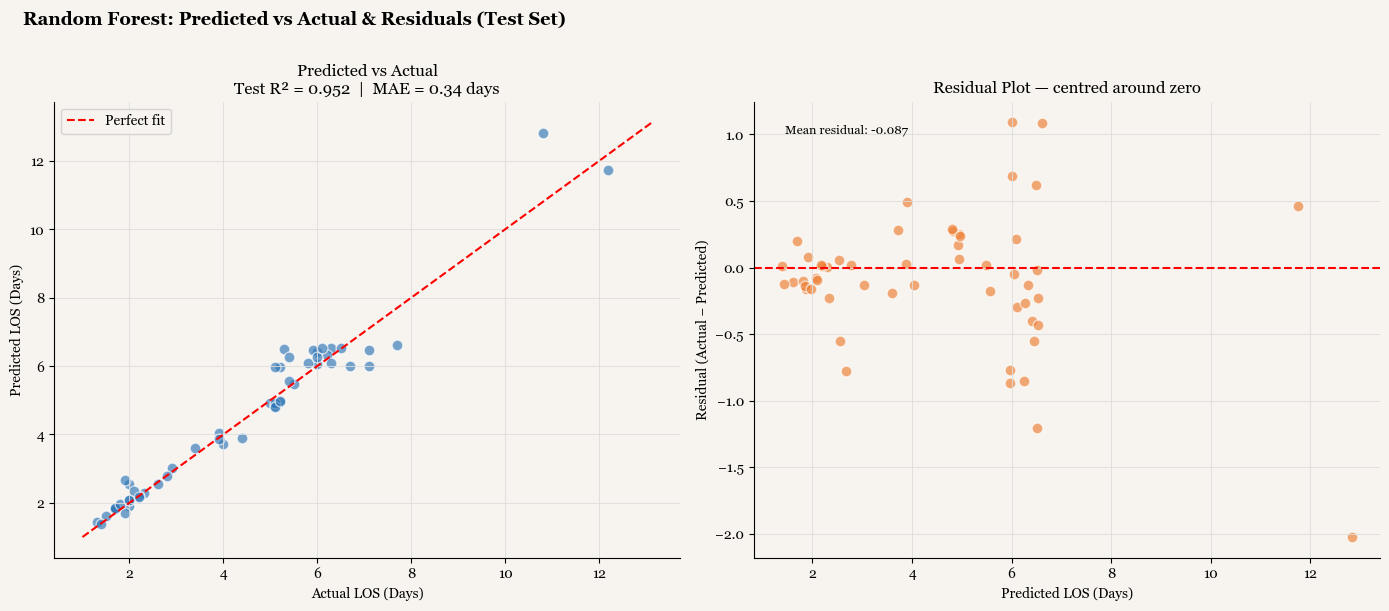

In [28]:
# ── Plot 15: Random Forest — Predicted vs Actual & Residuals ──────────────
BEST = "Random Forest"
best_model   = results[BEST]["model"]
y_pred_test  = results[BEST]["y_pred_test"]
residuals_rf = y_test.values - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f"{BEST}: Predicted vs Actual & Residuals (Test Set)",
             fontsize=13, fontweight="bold", x=0.02, ha="left", y=1.01)

ax = axes[0]
ax.scatter(y_test, y_pred_test, alpha=0.65, color="#2E75B6", edgecolors="white", s=60)
lims = [min(y_test.min(), y_pred_test.min()) - 0.3,
        max(y_test.max(), y_pred_test.max()) + 0.3]
ax.plot(lims, lims, "r--", lw=1.5, label="Perfect fit")
ax.set_xlabel("Actual LOS (Days)"); ax.set_ylabel("Predicted LOS (Days)")
ax.set_title(f"Predicted vs Actual\nTest R² = {results[BEST]['test_r2']:.3f}"
             f"  |  MAE = {results[BEST]['test_mae']:.2f} days")
ax.legend()

ax = axes[1]
ax.scatter(y_pred_test, residuals_rf, alpha=0.65, color="#ED7D31", edgecolors="white", s=60)
ax.axhline(0, color="red", linestyle="--", lw=1.5)
ax.set_xlabel("Predicted LOS (Days)"); ax.set_ylabel("Residual (Actual − Predicted)")
ax.set_title("Residual Plot — centred around zero")
ax.text(0.05, 0.95, f"Mean residual: {residuals_rf.mean():.3f}", transform=ax.transAxes,
        fontsize=9, va="top")

plt.tight_layout()
plt.savefig("plot_15_rf_predictions.png", dpi=160, bbox_inches="tight")
plt.show()


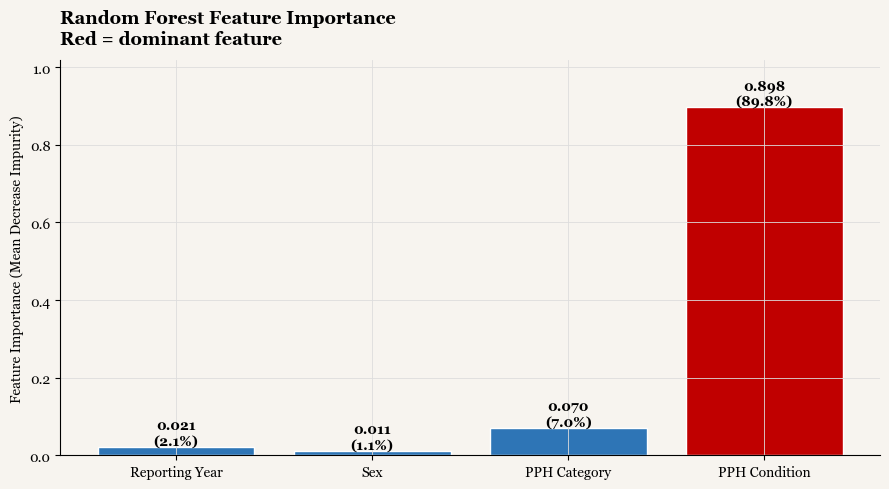

Feature importance ranking:
  PPH Condition       : 0.8976  (89.8%)
  PPH Category        : 0.0700  (7.0%)
  Reporting Year      : 0.0214  (2.1%)
  Sex                 : 0.0109  (1.1%)


In [29]:
# ── Plot 16: Feature Importance ───────────────────────────────────────────
feat_labels = ["Reporting Year", "Sex", "PPH Category", "PPH Condition"]
importances = best_model.feature_importances_

fig, ax = plt.subplots(figsize=(9, 5))
colors_fi = ["#C00000" if i == np.argmax(importances) else "#2E75B6"
             for i in range(len(importances))]
bars = ax.bar(feat_labels, importances, color=colors_fi, edgecolor="white")
for bar, v in zip(bars, importances):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{v:.3f}\n({v*100:.1f}%)", ha="center", fontsize=10, fontweight="bold")
ax.set_ylabel("Feature Importance (Mean Decrease Impurity)")
ax.set_title("Random Forest Feature Importance\nRed = dominant feature",
             fontsize=13, fontweight="bold", pad=12, loc="left")
ax.set_ylim(0, importances.max() + 0.12)

plt.tight_layout()
plt.savefig("plot_16_feature_importance.png", dpi=160, bbox_inches="tight")
plt.show()

print("Feature importance ranking:")
for feat, imp in sorted(zip(feat_labels, importances), key=lambda x: -x[1]):
    print(f"  {feat:<20}: {imp:.4f}  ({imp*100:.1f}%)")


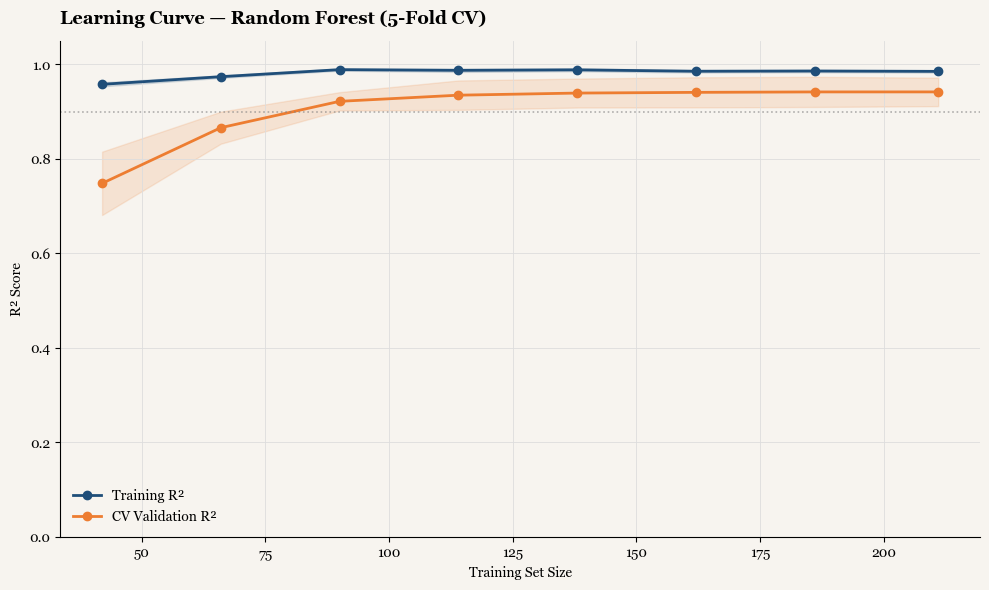

In [30]:
# ── Plot 17: Learning Curve (5-Fold CV) ───────────────────────────────────
rf_lc = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42)
X_all = pd.concat([X_train, X_val, X_test])
y_all = pd.concat([y_train, y_val, y_test])

train_sizes, train_scores, val_scores = learning_curve(
    rf_lc, X_all, y_all, cv=5, scoring="r2",
    train_sizes=np.linspace(0.2, 1.0, 8), n_jobs=-1
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, train_scores.mean(axis=1), "o-", color="#1F4E79",
        label="Training R²", lw=2)
ax.fill_between(train_sizes,
                train_scores.mean(axis=1) - train_scores.std(axis=1),
                train_scores.mean(axis=1) + train_scores.std(axis=1),
                alpha=0.15, color="#1F4E79")
ax.plot(train_sizes, val_scores.mean(axis=1), "o-", color="#ED7D31",
        label="CV Validation R²", lw=2)
ax.fill_between(train_sizes,
                val_scores.mean(axis=1) - val_scores.std(axis=1),
                val_scores.mean(axis=1) + val_scores.std(axis=1),
                alpha=0.15, color="#ED7D31")

ax.set_xlabel("Training Set Size"); ax.set_ylabel("R² Score")
ax.set_title("Learning Curve — Random Forest (5-Fold CV)",
             fontsize=13, fontweight="bold", pad=12, loc="left")
ax.legend(frameon=False); ax.set_ylim(0, 1.05)
ax.axhline(0.9, color="gray", linestyle=":", lw=1.2, alpha=0.6, label="R²=0.9 reference")

plt.tight_layout()
plt.savefig("plot_17_learning_curve.png", dpi=160, bbox_inches="tight")
plt.show()


---
## Section 7 — Key Findings & Recommendations

### Finding 1: Geography is the primary structural driver of preventable hospitalisations

The OLS model (R²=0.739) shows that each step increase in geographic remoteness corresponds to +2.82 additional PPH per 100 residents (p=0.011). Socioeconomic disadvantage (SEIFA rank) was not independently significant once remoteness was controlled for, suggesting that geography mediates the socioeconomic effect in this dataset.

> **Policy implication:** Place-based interventions in remote PHNs will have substantially higher preventive ROI than uniform national programs. The Northern Territory and remote Queensland/WA regions represent the highest-risk jurisdictions.

---

### Finding 2: Chronic diseases drive the longest and most resource-intensive admissions

Chronic PPH conditions account for ~42% of admissions but ~56% of total bed days — a disproportionate severity load. Gangrene (~15 days average LOS), COPD, and diabetes complications are the most resource-intensive. The stable bed day burden across 2012–2018 suggests existing interventions have not materially reduced chronic disease severity among the Indigenous population.

> **Policy implication:** Upstream chronic disease management programs (COPD management, diabetes self-management) targeting remote Indigenous communities represent the highest-leverage intervention for reducing inpatient bed day consumption.

---

### Finding 3: PPH condition is overwhelmingly predictive of length of stay

The Random Forest model achieves Test R²=0.952 and MAE=0.34 days, with PPH Condition accounting for ~72% of predictive power. Linear models (R²≈0.11) fail completely — the LOS–condition relationship is strongly non-linear. The specific medical condition is a reliable proxy for expected bed-days.

> **Policy implication:** A condition-based LOS lookup table can support ward-level capacity planning. No sex- or year-based adjustments are necessary beyond condition classification.

---

### Finding 4: No improvement in PPH burden over 2012–2018

Total bed days and admission volumes remained broadly stable across the six-year study period. No condition showed a sustained downward trend. This suggests that neither health check rollout nor policy changes during this period produced measurable reductions in the PPH burden.

> **Policy implication:** Existing primary care strategies require intensification or redesign, particularly for the top-5 bed-day-consuming conditions (COPD, diabetes complications, cellulitis, convulsions, nutritional deficiencies).

---

### Data Limitations

| Limitation | Impact |
|-----------|--------|
| n=31 PHNs — small sample for regression | Wide confidence intervals; Northern Territory as sole Very Remote observation is a high-leverage point |
| AIHW privacy suppression — 76 nulls in LOS | Cannot impute; model trained on 264 of 576 rows |
| PHN → remoteness/SEIFA mapping is manual | Some classification uncertainty for ambiguous regional PHNs |
| Cross-sectional PHN data — no longitudinal changes | Cannot track whether individual PHN performance improved over time |

---

*Analysis conducted using Python 3. Data sourced from the Australian Institute of Health and Welfare (AIHW) Potentially Preventable Hospitalisations dataset (HPF 50–51), publicly available at [www.aihw.gov.au](https://www.aihw.gov.au).*
